# RQ2 Notebook 04 — Duration and Mitigation Stage

**RQ2.2: How long do downstream projects stay exposed, and where in the upstream lifecycle
does that exposure end?**

This notebook tests RQ1's central claim. RQ1 argues the release-to-disclosure interval is
"the available adoption window" and marks pattern `S1` as `Risk for downstream: No`. `S1`
covers 258 CVEs — 81.9% of silent fixes — so it is the single load-bearing row in RQ1's
risk table.

If downstream projects mostly mitigate *after* disclosure rather than inside that window,
the window exists but goes unused, and `S1 = Risk: No` does not survive.

**Input:** `rq2_master_pairwise.csv` (1,677 pairs / 191 CVEs / 742 repos) from notebook 02,
after the Step 10b exclusion of adoptions that predate the upstream fix.

**Produces:** `T3`, `T4`, `F3`, `F4`.

In [74]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
rng = np.random.default_rng(20260811)

OUT = Path('../../data/rq2')

master = pd.read_csv(OUT / 'rq2_master_pairwise.csv')
for c in ['adoption_date', 'report_date', 'fix_date', 'release_date', 'disclosure_date']:
    master[c] = pd.to_datetime(master[c], errors='coerce')

PATTERN_ORDER = ['S1', 'S2', 'S3', 'T1', 'T2', 'T3', 'T5']
SEVERITY_ORDER = ['Critical', 'High', 'Medium', 'Low', 'Unknown']

print(f'pairs : {len(master):,}')
print(f'CVEs  : {master.CVE.nunique()}')
print(f'repos : {master.downstream_repo.nunique()}')
master.head(3)

pairs : 1,677
CVEs  : 191
repos : 742


,CVE,upstream_GA,downstream_GA,downstream_repo,commit_url,adoption_date,commit_n_CVEs,class,pattern,original_pattern,gad_reclassified,severity,cvss,cwe,report_date,fix_date,release_date,disclosure_date,delay_report,delay_fix,delay_release,delay_disclosure,mitigation_stage,disclosure_year,dependents,downstream_usage_num,downstream_loc,downstream_class_num,upstream_stars_at_fix
0,CVE-2021-37714,org.jsoup:jsoup,com.github.btheu.estivate:estivate,btheu/estivate,https://github.com/btheu/estivate/commit/22adf...,2021-12-03 15:44:15,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,110.554502,110.134062,110.003472,107.655729,After Disclosure,2021,244,0,3801.0,102.0,8521.0
1,CVE-2021-37714,org.jsoup:jsoup,com.jcabi:jcabi-http,jcabi/jcabi-http,https://github.com/jcabi/jcabi-http/commit/1a2...,2021-08-16 23:00:43,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,1.857604,1.437164,1.306574,-1.041169,Release->Disclosure,2021,244,0,3957.5,89.5,8521.0
2,CVE-2021-37714,org.jsoup:jsoup,in.ashwanthkumar:gocd-java-client,ashwanthkumar/gocd-java-client,https://github.com/ashwanthkumar/gocd-java-cli...,2021-09-30 23:03:50,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,46.859769,46.439329,46.308738,43.960995,After Disclosure,2021,244,0,1339.5,27.0,8521.0


---
## Step 1 — Universal mitigation stage

Notebook 02 assigned a **pattern-native** stage: the interval between consecutive events in
that pattern's own ordering. That is faithful but produces 15 distinct labels, because each
pattern has a different event sequence. It cannot be compared across patterns.

For cross-pattern comparison we need one scale that means the same thing everywhere:

> **Was the fixed release available, and was the vulnerability still private?**

```
Before release  ->  Safe window  ->  After disclosure
```

This is defined from the two anchored delays, **not** from which upstream event happened
most recently. That distinction matters: in patterns where disclosure precedes release
(S2, S3, T2, T3, T5), release is the most recent event even though the vulnerability is
already public. An order-based rule would label 100 such pairs as safe-window mitigations
when the flaw had been public for weeks.

**Reading the scale:**

| Stage | Meaning |
|---|---|
| Before release | Fix committed, release not yet shipped |
| **Safe window** | **Fixed release available, vulnerability still private** |
| After disclosure | Vulnerability already public when downstream mitigated |

In [75]:
# Exposure stage. Defined from the two facts that matter, not from event order:
#   was the fixed release out?            delay_release >= 0
#   was the vulnerability still private?  delay_disclosure < 0
# Ordering the checks this way is correct for every pattern, including those where
# disclosure precedes release (S2, S3, T2, T3, T5). Asking "which upstream event was
# most recent" would wrongly label those as safe.
LADDER = ['Before release', 'Safe window', 'After disclosure']

def exposure_stage(row):
    if row.delay_disclosure >= 0:
        return 'After disclosure'
    if row.delay_release >= 0:
        return 'Safe window'
    return 'Before release'


master['stage'] = pd.Categorical(master.apply(exposure_stage, axis=1), categories=LADDER, ordered=True)
master['after_disclosure'] = master.stage.eq('After disclosure').astype(int)

stage_overall = (
    master.stage.value_counts().reindex(LADDER)
    .rename_axis('Universal stage').reset_index(name='Pairs')
)
stage_overall['%'] = (100 * stage_overall.Pairs / len(master)).round(1)
display(stage_overall)

print(f'Mitigated AFTER public disclosure : {master.after_disclosure.sum():,} of {len(master):,} '
      f'({100 * master.after_disclosure.mean():.1f}%)')
print(f'Mitigated inside the safe window  : {(master.stage == "Safe window").sum():,} '
      f'({100 * (master.stage == "Safe window").mean():.1f}%)')

,Universal stage,Pairs,%
0,Before release,25,1.5
1,Safe window,222,13.2
2,After disclosure,1430,85.3


Mitigated AFTER public disclosure : 1,430 of 1,677 (85.3%)
Mitigated inside the safe window  : 222 (13.2%)


---
## Step 2 — Measure the upstream window from the same data

RQ1 reported the S1 release-to-disclosure window as 29.86 days. Rather than hardcoding that
number, we recompute the upstream windows here from the same date columns, at **CVE level**
(deduplicated), so the comparison in `T3` is internally consistent and cannot drift from a
stale figure.

Note this recomputes over the 195 CVEs present in RQ2, not RQ1's full 593, so small
differences from RQ1's published values are expected.

In [76]:
cve_level = master.drop_duplicates('CVE')[
    ['CVE', 'class', 'pattern', 'severity', 'fix_date', 'release_date', 'disclosure_date', 'dependents']
].copy()

cve_level['window_fix_to_release'] = (
    cve_level.release_date - cve_level.fix_date).dt.total_seconds() / 86400
cve_level['window_release_to_disclosure'] = (
    cve_level.disclosure_date - cve_level.release_date).dt.total_seconds() / 86400

upstream_windows = (
    cve_level.groupby('pattern')
    .agg(CVEs=('CVE', 'size'),
         upstream_fix_to_release=('window_fix_to_release', 'median'),
         upstream_release_to_disclosure=('window_release_to_disclosure', 'median'))
    .reindex(PATTERN_ORDER).dropna(how='all').round(2)
)
display(upstream_windows)

print('RQ1 published S1 release-to-disclosure median: 29.86 days')
print(f"Recomputed here on RQ2's 195 CVEs           : "
      f"{upstream_windows.loc['S1', 'upstream_release_to_disclosure']:.2f} days")

,CVEs,upstream_fix_to_release,upstream_release_to_disclosure
pattern,,,
S1,95,6.59,13.12
S2,6,82.45,-25.02
S3,4,73.97,-117.54
T1,75,6.59,21.49
T2,6,171.39,-149.27
T3,4,4.32,-13.33
T5,1,0.02,-5.15


RQ1 published S1 release-to-disclosure median: 29.86 days
Recomputed here on RQ2's 195 CVEs           : 13.12 days


---
## T3 — Downstream delay by pattern, against the upstream window

The confrontation table. For each pattern:

- **Upstream window** — how long the safe adoption period lasted (release to disclosure)
- **Observed delay** — how long downstream actually took after the fixed release existed
- **Ratio** — observed delay divided by the window

A ratio above 1 means the median downstream project missed the window entirely.

Patterns where disclosure precedes release have no safe window by construction; their
window is reported as negative and the ratio is omitted.

In [77]:
rows = []
for pat in PATTERN_ORDER:
    sub = master[master.pattern.eq(pat)]
    if sub.empty:
        continue
    win = upstream_windows.loc[pat, 'upstream_release_to_disclosure'] if pat in upstream_windows.index else np.nan
    med_rel = sub.delay_release.median()
    rows.append({
        'Pattern': pat,
        'Class': sub['class'].iloc[0],
        'CVEs': sub.CVE.nunique(),
        'Pairs': len(sub),
        'Upstream window (d)': round(win, 1) if pd.notna(win) else np.nan,
        'delay_fix med [IQR]': f'{sub.delay_fix.median():.1f} [{sub.delay_fix.quantile(.25):.1f}, {sub.delay_fix.quantile(.75):.1f}]',
        'delay_release med [IQR]': f'{med_rel:.1f} [{sub.delay_release.quantile(.25):.1f}, {sub.delay_release.quantile(.75):.1f}]',
        'delay_disclosure med [IQR]': f'{sub.delay_disclosure.median():.1f} [{sub.delay_disclosure.quantile(.25):.1f}, {sub.delay_disclosure.quantile(.75):.1f}]',
        'delay_report med': round(sub.delay_report.median(), 1) if sub.delay_report.notna().any() else np.nan,
        'Delay / window': round(med_rel / win, 2) if (pd.notna(win) and win > 0) else np.nan,
    })

T3 = pd.DataFrame(rows)
display(T3)

print('Delay / window divides the median delay by the median window. It is a ratio of two')
print('medians, not the median of per-pair ratios.')
print('Ratio > 1 means the median downstream project mitigated after the safe window closed.')
print('Patterns with n < 10 CVEs are shown for completeness but must not carry claims.')

,Pattern,Class,CVEs,Pairs,Upstream window (d),delay_fix med [IQR],delay_release med [IQR],delay_disclosure med [IQR],delay_report med,Delay / window
0,S1,Silent,95,1012,13.1,"131.9 [61.9, 440.1]","90.7 [15.2, 389.4]","63.6 [3.5, 259.5]",NaN,6.91
1,S2,Silent,6,68,-25.0,"146.6 [78.9, 345.9]","58.5 [-22.2, 264.2]","111.2 [44.6, 290.4]",NaN,NaN
2,S3,Silent,4,20,-117.5,"99.9 [77.2, 226.6]","16.7 [-0.8, 135.3]","127.2 [118.9, 253.3]",NaN,NaN
3,T1,Transparent,75,521,21.5,"107.7 [31.7, 304.8]","85.1 [13.7, 259.7]","32.3 [0.9, 156.6]",133.4,3.96
4,T2,Transparent,6,34,-149.3,"202.6 [57.4, 712.7]","31.2 [-336.5, 556.3]","75.9 [20.2, 680.6]",203.4,NaN
5,T3,Transparent,4,21,-13.3,"118.6 [54.9, 408.9]","113.1 [32.8, 408.7]","411.5 [115.7, 542.4]",119.3,NaN
6,T5,Transparent,1,1,-5.2,"83.4 [83.4, 83.4]","83.4 [83.4, 83.4]","88.5 [88.5, 88.5]",88.9,NaN


Delay / window divides the median delay by the median window. It is a ratio of two
medians, not the median of per-pair ratios.
Ratio > 1 means the median downstream project mitigated after the safe window closed.
Patterns with n < 10 CVEs are shown for completeness but must not carry claims.


---
## T4 — Mitigation stage by pattern

Two views of the same data.

**Panel A** uses the universal ladder, so patterns are directly comparable.

**Panel B** is the pattern-native stage from notebook 02, which respects each pattern's own
event ordering. Use it to check that Panel A is not hiding something specific to one
sequence.

In [78]:
T4_counts = (
    pd.crosstab(master.pattern, master.stage)
    .reindex(index=PATTERN_ORDER).dropna(how='all').fillna(0).astype(int)
)
T4_counts.insert(0, 'Class', [master.loc[master.pattern.eq(p), 'class'].iloc[0] for p in T4_counts.index])
T4_counts.insert(1, 'Pairs', [int(master.pattern.eq(p).sum()) for p in T4_counts.index])
print('Panel A - universal stage, counts')
display(T4_counts)

T4_pct = (
    pd.crosstab(master.pattern, master.stage, normalize='index')
    .reindex(index=PATTERN_ORDER).dropna(how='all').mul(100).round(1)
)
print('Panel A - universal stage, row %')
display(T4_pct)

print('By class')
display(pd.crosstab(master['class'], master.stage, normalize='index').mul(100).round(1))

print('Panel B - pattern-native stage (from notebook 02)')
display(pd.crosstab(master.pattern, master.mitigation_stage).reindex(index=PATTERN_ORDER).dropna(how='all').fillna(0).astype(int))

T4 = T4_counts

Panel A - universal stage, counts


stage,Class,Pairs,Before release,Safe window,After disclosure
pattern,,,,,
S1,Silent,1012,7,111,894
S2,Silent,68,0,0,68
S3,Silent,20,0,0,20
T1,Transparent,521,11,111,399
T2,Transparent,34,7,0,27
T3,Transparent,21,0,0,21
T5,Transparent,1,0,0,1


Panel A - universal stage, row %


stage,Before release,Safe window,After disclosure
pattern,,,
S1,0.7,11.0,88.3
S2,0.0,0.0,100.0
S3,0.0,0.0,100.0
T1,2.1,21.3,76.6
T2,20.6,0.0,79.4
T3,0.0,0.0,100.0
T5,0.0,0.0,100.0


By class


stage,Before release,Safe window,After disclosure
class,,,
Silent,0.6,10.1,89.3
Transparent,3.1,19.2,77.6


Panel B - pattern-native stage (from notebook 02)


mitigation_stage,After Disclosure,After Release,Disclosure->Release,Fix->Disclosure,Fix->Release,Release->Disclosure,Report->Disclosure
pattern,,,,,,,
S1,894,0,0,0,7,111,0
S2,0,49,19,0,0,0,0
S3,0,12,0,0,8,0,0
T1,399,0,0,0,11,102,9
T2,0,18,9,7,0,0,0
T3,0,20,0,0,1,0,0
T5,0,1,0,0,0,0,0


---
## The S1 test

RQ1's only `Risk for downstream: No` row. The claim is that because the fixed release
precedes disclosure, downstream projects had a safe window in which to adopt.

This section tests that claim on S1 alone rather than on the pooled sample, and pairs it
with T1 — the transparent pattern with the same release-before-disclosure ordering — so the
comparison isolates reporting behavior from event ordering.

In [79]:
def stage_profile(pat):
    sub = master[master.pattern.eq(pat)]
    prof = sub.stage.value_counts().reindex(LADDER).fillna(0).astype(int)
    return {
        'Pattern': pat,
        'Class': sub['class'].iloc[0],
        'CVEs': sub.CVE.nunique(),
        'Pairs': len(sub),
        **{f'{k} (n)': int(v) for k, v in prof.items()},
        'Safe window %': round(100 * (sub.stage == 'Safe window').mean(), 1),
        'After disclosure %': round(100 * (sub.stage == 'After disclosure').mean(), 1),
        'Median delay_release (d)': round(sub.delay_release.median(), 1),
        'Upstream window (d)': round(upstream_windows.loc[pat, 'upstream_release_to_disclosure'], 1),
    }

s1_test = pd.DataFrame([stage_profile('S1'), stage_profile('T1')])
display(s1_test.T)

s1 = master[master.pattern.eq('S1')]
print(f"S1: {(s1.stage == 'After disclosure').sum()} of {len(s1)} pairs "
      f"({100 * (s1.stage == 'After disclosure').mean():.1f}%) mitigated AFTER public disclosure.")
print(f"S1: only {(s1.stage == 'Safe window').sum()} pairs "
      f"({100 * (s1.stage == 'Safe window').mean():.1f}%) used the safe window.")
print()
print("VERDICT on RQ1's 'S1 = Risk for downstream: No':")
if (s1.stage == 'After disclosure').mean() > 0.5:
    print("  NOT SUPPORTED. The window exists upstream but the majority of downstream")
    print("  projects mitigate only after the vulnerability is already public.")
else:
    print("  SUPPORTED. Most downstream mitigation occurs before disclosure.")

,0,1
Pattern,S1,T1
Class,Silent,Transparent
CVEs,95,75
Pairs,1012,521
Before release (n),7,11
Safe window (n),111,111
After disclosure (n),894,399
Safe window %,11.0,21.3
After disclosure %,88.3,76.6
Median delay_release (d),90.7,85.1


S1: 894 of 1012 pairs (88.3%) mitigated AFTER public disclosure.
S1: only 111 pairs (11.0%) used the safe window.

VERDICT on RQ1's 'S1 = Risk for downstream: No':
  NOT SUPPORTED. The window exists upstream but the majority of downstream
  projects mitigate only after the vulnerability is already public.


---
## F3 — Mitigation stage by group (headline figure)

100% stacked bars on the universal ladder. Groups with fewer than 10 CVEs are omitted —
they appear in `T4` but cannot support a visual claim.

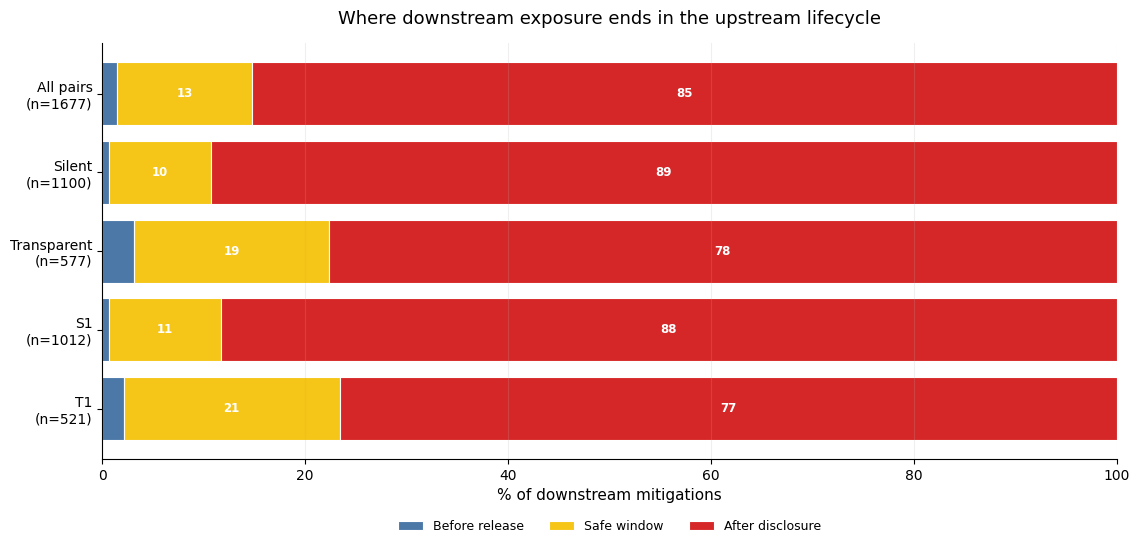

In [80]:
STAGE_COLORS = {
    'Before release': '#4c78a8',
    'Safe window': '#f5c518',
    'After disclosure': '#d62728',
}

groups = []
for label, sub in [('All pairs', master),
                   ('Silent', master[master['class'].eq('Silent')]),
                   ('Transparent', master[master['class'].eq('Transparent')])]:
    groups.append((f'{label}\n(n={len(sub)})', sub))
for pat in PATTERN_ORDER:
    sub = master[master.pattern.eq(pat)]
    if sub.CVE.nunique() >= 10:
        groups.append((f'{pat}\n(n={len(sub)})', sub))

labels = [g[0] for g in groups]
fig, ax = plt.subplots(figsize=(11.5, 5.6))
left = np.zeros(len(groups))
for stage in LADDER:
    vals = np.array([100 * (sub.stage == stage).mean() for _, sub in groups])
    ax.barh(labels, vals, left=left, color=STAGE_COLORS[stage], label=stage,
            edgecolor='white', linewidth=0.8)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v >= 5:
            ax.text(l + v / 2, i, f'{v:.0f}', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('% of downstream mitigations', fontsize=11)
ax.set_title('Where downstream exposure ends in the upstream lifecycle', fontsize=13, pad=14)
ax.invert_yaxis()
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=9)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
fig.savefig(OUT / 'F3_mitigation_stage.png', dpi=200, bbox_inches='tight')
plt.show()

In [81]:
# T4c - downstream adoption by RQ1 lifecycle interval, and elapsed time within that interval.
# Stage names follow RQ1's event vocabulary (Fix -> Release -> Disclosure): each interval is
# named by the events that bound it, and its clock starts at the event that OPENS it.
#   Fix -> Release         delay_fix         adopted after the fix, before the release, still private
#   Release -> Disclosure  delay_release     the safe window
#   After Disclosure       delay_disclosure
# Built from the same `groups` list as F3, so figure and table cannot diverge.
# Bins are DISJOINT and sum to the interval; intervals are mutually exclusive and sum to the group.
# Groups are NESTED: Silent + Transparent = All pairs; S1 is a subset of Silent, T1 of Transparent.
INTERVALS = [('Fix -> Release',        'Before release',   'delay_fix',        'Fix'),
             ('Release -> Disclosure', 'Safe window',      'delay_release',    'Release'),
             ('After Disclosure',      'After disclosure', 'delay_disclosure', 'Disclosure')]
BIN_EDGES  = [-1e-9, 1, 7, 30, 90, np.inf]
BIN_LABELS = ['<=1 d', '1-7 d', '7-30 d', '30-90 d', '>90 d']

rows = []
for label, sub in groups:
    name, n = label.split('\n')[0], len(sub)
    block = []
    for interval, stage_key, col, opening_event in INTERVALS:
        s = sub[sub.stage == stage_key]
        r = {'Group': name, 'Adoption interval': interval,
             'Clock': f'days since {opening_event}',
             'Pairs': len(s), '% of group': round(100 * len(s) / n, 1),
             'Median d': round(s[col].median(), 1) if len(s) else np.nan}
        counts = (pd.cut(s[col], BIN_EDGES, labels=BIN_LABELS)
                    .value_counts().reindex(BIN_LABELS).fillna(0).astype(int))
        r.update({b: int(counts[b]) for b in BIN_LABELS})
        block.append(r)
    block.append({'Group': name, 'Adoption interval': 'All', 'Clock': '', 'Pairs': n,
                  '% of group': 100.0, 'Median d': np.nan,
                  **{b: int(sum(x[b] for x in block)) for b in BIN_LABELS}})
    rows += block

T4c = pd.DataFrame(rows)

# integrity: bins reconstruct each interval, intervals reconstruct each group
_iv = T4c[T4c['Adoption interval'].ne('All')]
assert (_iv[BIN_LABELS].sum(axis=1) == _iv.Pairs).all(), 'bins do not sum to interval'
for _g in T4c.Group.unique():
    _tot = T4c[(T4c.Group == _g) & T4c['Adoption interval'].eq('All')].Pairs.iloc[0]
    assert T4c[(T4c.Group == _g) & T4c['Adoption interval'].ne('All')].Pairs.sum() == _tot, \
        f'intervals do not sum to group {_g}'
# integrity: the % of group column must reproduce the stage split used by F3
assert T4c.loc[T4c.Group.eq('All pairs') & T4c['Adoption interval'].eq('After Disclosure'),
               'Pairs'].iloc[0] == int(master.after_disclosure.sum()), 'F3 mismatch'

display(T4c)
print(T4c.to_latex(index=False))


,Group,Adoption interval,Clock,Pairs,% of group,Median d,<=1 d,1-7 d,7-30 d,30-90 d,>90 d
0,All pairs,Fix -> Release,days since Fix,25,1.5,14.1,4,2,13,3,3
1,All pairs,Release -> Disclosure,days since Release,222,13.2,10.2,28,67,57,31,39
2,All pairs,After Disclosure,days since Disclosure,1430,85.3,88.1,68,173,201,276,712
3,All pairs,All,,1677,100.0,NaN,100,242,271,310,754
4,Silent,Fix -> Release,days since Fix,7,0.6,27.2,0,1,3,0,3
5,Silent,Release -> Disclosure,days since Release,111,10.1,13.6,9,35,34,11,22
6,Silent,After Disclosure,days since Disclosure,982,89.3,95.1,47,125,132,179,499
7,Silent,All,,1100,100.0,NaN,56,161,169,190,524
8,Transparent,Fix -> Release,days since Fix,18,3.1,11.2,4,1,10,3,0
9,Transparent,Release -> Disclosure,days since Release,111,19.2,8.7,19,32,23,20,17


\begin{tabular}{lllrrrrrrrr}
\toprule
Group & Adoption interval & Clock & Pairs & % of group & Median d & <=1 d & 1-7 d & 7-30 d & 30-90 d & >90 d \\
\midrule
All pairs & Fix -> Release & days since Fix & 25 & 1.500000 & 14.100000 & 4 & 2 & 13 & 3 & 3 \\
All pairs & Release -> Disclosure & days since Release & 222 & 13.200000 & 10.200000 & 28 & 67 & 57 & 31 & 39 \\
All pairs & After Disclosure & days since Disclosure & 1430 & 85.300000 & 88.100000 & 68 & 173 & 201 & 276 & 712 \\
All pairs & All &  & 1677 & 100.000000 & NaN & 100 & 242 & 271 & 310 & 754 \\
Silent & Fix -> Release & days since Fix & 7 & 0.600000 & 27.200000 & 0 & 1 & 3 & 0 & 3 \\
Silent & Release -> Disclosure & days since Release & 111 & 10.100000 & 13.600000 & 9 & 35 & 34 & 11 & 22 \\
Silent & After Disclosure & days since Disclosure & 982 & 89.300000 & 95.100000 & 47 & 125 & 132 & 179 & 499 \\
Silent & All &  & 1100 & 100.000000 & NaN & 56 & 161 & 169 & 190 & 524 \\
Transparent & Fix -> Release & days since Fix & 18 &

In [82]:
# T4d - cumulative adoption timing: how soon after each upstream event downstream adopted.
# Uses the same `groups` list as F3 and T4c, so all three stay in sync.
#
# READ WITH CARE:
#   * The three rows per group are the SAME pairs measured against three different
#     upstream events. They are three views of one set of adoptions, not three groups.
#     Do not sum down the table.
#   * Groups are NESTED: Silent + Transparent = All pairs; S1 is a subset of Silent,
#     T1 a subset of Transparent.
#   * "Before event" = delay < 0, i.e. adoption preceded that upstream event. Always 0
#     for the fix row by construction (filter step 5 removed delay_fix < 0).
#   * "<=X d" columns are CUMULATIVE and nest: <=7d already contains <=3d contains <=1d.
#   * Only "Before event" + "<=365d" + ">365d" partition a row; asserted below.
REF_EVENTS = [('Upstream fix', 'delay_fix'),
              ('Upstream release', 'delay_release'),
              ('Public disclosure', 'delay_disclosure')]
THRESHOLDS = [1, 3, 7, 30, 90, 365]

rows = []
for label, sub in groups:
    n = len(sub)
    for ref_label, col in REF_EVENTS:
        x = sub[col]
        r = {'Group': label.split('\n')[0], 'Measured from': ref_label, 'Pairs': n,
             'Before event': int((x < 0).sum())}
        for t in THRESHOLDS:
            r[f'<={t}d'] = int(((x >= 0) & (x <= t)).sum())
        r['>365d'] = int((x > 365).sum())
        rows.append(r)

T4d = pd.DataFrame(rows)

# integrity: the three disjoint columns must reconstruct the group size
assert (T4d['Before event'] + T4d['<=365d'] + T4d['>365d'] == T4d.Pairs).all(), \
    'partition check failed'
# integrity: the disclosure row must agree with T4c (before disclosure = not "After disclosure")
_chk = T4d[T4d['Measured from'].eq('Public disclosure')].set_index('Group')['Before event']
assert _chk['All pairs'] == (master.stage != 'After disclosure').sum(), 'T4c mismatch'

display(T4d)

COUNT_COLS = ['Before event'] + [f'<={t}d' for t in THRESHOLDS] + ['>365d']
T4d_fmt = T4d[['Group', 'Measured from', 'Pairs']].copy()
for c in COUNT_COLS:
    T4d_fmt[c] = [f'{v:,} ({100 * v / n:.1f}%)' for v, n in zip(T4d[c], T4d.Pairs)]
print(T4d_fmt.to_string(index=False))
print()
print(T4d_fmt.to_latex(index=False))


,Group,Measured from,Pairs,Before event,<=1d,<=3d,<=7d,<=30d,<=90d,<=365d,>365d
0,All pairs,Upstream fix,1677,0,19,38,79,300,632,1240,437
1,All pairs,Upstream release,1677,62,37,91,226,498,792,1218,397
2,All pairs,Public disclosure,1677,247,68,173,241,442,718,1122,308
3,Silent,Upstream fix,1100,0,2,12,40,162,376,792,308
4,Silent,Upstream release,1100,34,18,54,160,334,521,777,289
5,Silent,Public disclosure,1100,118,47,128,172,304,483,768,214
6,Transparent,Upstream fix,577,0,17,26,39,138,256,448,129
7,Transparent,Upstream release,577,28,19,37,66,164,271,441,108
8,Transparent,Public disclosure,577,129,21,45,69,138,235,354,94
9,S1,Upstream fix,1012,0,2,11,39,154,343,725,287


      Group     Measured from  Pairs Before event      <=1d        <=3d        <=7d       <=30d       <=90d        <=365d       >365d
  All pairs      Upstream fix   1677     0 (0.0%) 19 (1.1%)   38 (2.3%)   79 (4.7%) 300 (17.9%) 632 (37.7%) 1,240 (73.9%) 437 (26.1%)
  All pairs  Upstream release   1677    62 (3.7%) 37 (2.2%)   91 (5.4%) 226 (13.5%) 498 (29.7%) 792 (47.2%) 1,218 (72.6%) 397 (23.7%)
  All pairs Public disclosure   1677  247 (14.7%) 68 (4.1%) 173 (10.3%) 241 (14.4%) 442 (26.4%) 718 (42.8%) 1,122 (66.9%) 308 (18.4%)
     Silent      Upstream fix   1100     0 (0.0%)  2 (0.2%)   12 (1.1%)   40 (3.6%) 162 (14.7%) 376 (34.2%)   792 (72.0%) 308 (28.0%)
     Silent  Upstream release   1100    34 (3.1%) 18 (1.6%)   54 (4.9%) 160 (14.5%) 334 (30.4%) 521 (47.4%)   777 (70.6%) 289 (26.3%)
     Silent Public disclosure   1100  118 (10.7%) 47 (4.3%) 128 (11.6%) 172 (15.6%) 304 (27.6%) 483 (43.9%)   768 (69.8%) 214 (19.5%)
Transparent      Upstream fix    577     0 (0.0%) 17 (2.9%)   

In [ ]:
# T17 - downstream adoption variation under an IDENTICAL upstream fix.
# Holding the CVE fixed holds the upstream side fixed by construction: same fix commit,
# same release, same availability date. Any remaining spread is downstream behaviour.
# Restricted to pairs where the fix was already installable (delay_release >= 0).
var = master[master.delay_release >= 0].copy()
var['y'] = np.log1p(var.delay_release)          # delays are heavily right-skewed

def _icc(df, key):
    """One-way random-effects ICC: share of variance attributable to the grouping."""
    g = df.groupby(key).y
    k, n, gm = g.ngroups, len(df), df.y.mean()
    ssb = (g.count() * (g.mean() - gm) ** 2).sum()
    ssw = ((df.y - g.transform('mean')) ** 2).sum()
    msb, msw = ssb / (k - 1), ssw / (n - k)
    sizes = g.count()
    k0 = (n - (sizes ** 2).sum() / n) / (k - 1)   # unequal-group-size correction
    v = max((msb - msw) / k0, 0)
    return {'Grouping': key, 'Groups': k, 'Pairs': n,
            'ICC': round(v / (v + msw), 3), 'Within-group %': round(100 * msw / (v + msw), 1)}

T17b = pd.DataFrame([_icc(var, 'CVE'), _icc(var, 'downstream_repo')])
display(T17b)

# per-CVE spread, for CVEs with enough observed adoptions to show a distribution
MIN_N = 10
keep = master.CVE.value_counts()
keep = keep[keep >= MIN_N].index
rows = []
for c in keep:
    s = master[master.CVE.eq(c)]
    x = s.delay_release
    rows.append({'CVE': c, 'upstream': s.upstream_GA.iloc[0].split(':')[-1],
                 'pattern': s.pattern.iloc[0], 'n': len(s),
                 'release': str(s.release_date.iloc[0])[:10],
                 'min': round(x.min()), 'p25': round(x.quantile(.25)),
                 'median': round(x.median()), 'p75': round(x.quantile(.75)),
                 'max': round(x.max()),
                 'within 7d %': round(100 * (x <= 7).mean()),
                 'within 30d %': round(100 * (x <= 30).mean()),
                 'pre-disclosure %': round(100 * (s.delay_disclosure < 0).mean())})
T17a = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
display(T17a)

print(f'CVEs with >={MIN_N} observed adoptions: {len(T17a)} covering {T17a.n.sum()} pairs')
print(f'median within-CVE spread (max - min): {(T17a["max"] - T17a["min"]).median():.0f} days')
print(f'median within-CVE IQR width         : {(T17a.p75 - T17a.p25).median():.0f} days')


---
## F4 — Mitigation timing relative to disclosure

Zero is the NVD disclosure date. Mass to the right of zero is exposure that persisted after
the vulnerability became public. The x-axis uses a signed log scale because delays span
from days to years.

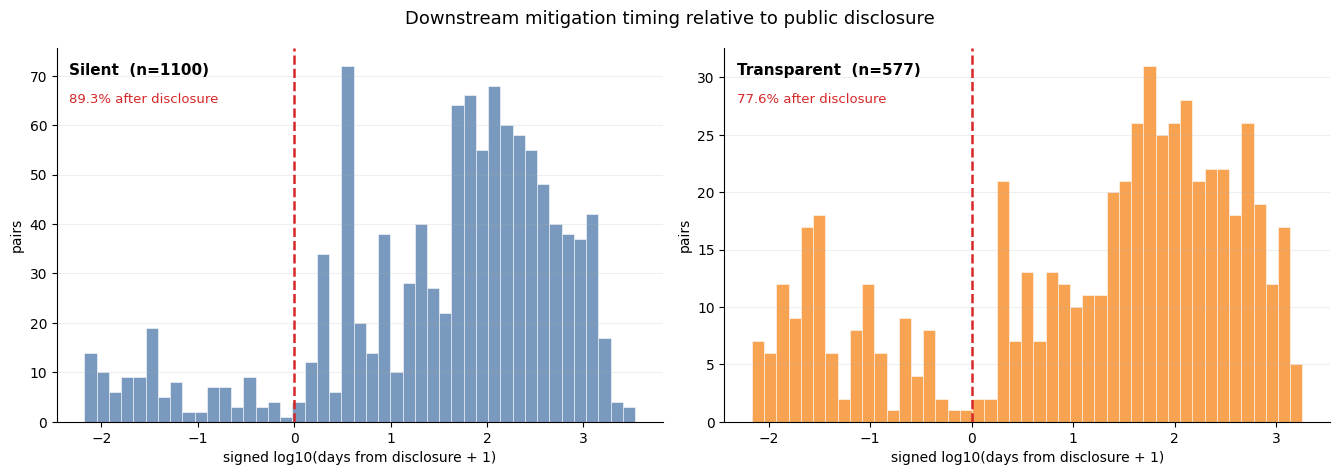

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

def signed_log(v):
    return np.sign(v) * np.log10(np.abs(v) + 1)

for ax, (label, color) in zip(axes, [('Silent', '#4c78a8'), ('Transparent', '#f58518')]):
    sub = master[master['class'].eq(label)]
    ax.hist(signed_log(sub.delay_disclosure.dropna()), bins=45, color=color,
            alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#d62728', linewidth=1.8, linestyle='--')
    ax.text(0.02, 0.96, f'{label}  (n={len(sub)})', transform=ax.transAxes,
            fontsize=11, va='top', fontweight='bold')
    ax.text(0.02, 0.88,
            f'{100 * (sub.delay_disclosure > 0).mean():.1f}% after disclosure',
            transform=ax.transAxes, fontsize=9.5, va='top', color='#d62728')
    ax.set_xlabel('signed log10(days from disclosure + 1)', fontsize=10)
    ax.set_ylabel('pairs', fontsize=10)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Downstream mitigation timing relative to public disclosure', fontsize=13)
fig.tight_layout()
fig.savefig(OUT / 'F4_timing_vs_disclosure.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Model — what predicts mitigating after disclosure?

Outcome: `after_disclosure` (1 if the vulnerability was already public when downstream
mitigated).

**Why a cluster bootstrap rather than analytic standard errors.** The 1,797 pairs come from
only 779 downstream repositories, and pairs within a repo are not independent — one
dependency bump can resolve several CVEs at once. Resampling *repositories* with
replacement preserves that structure. Analytic SEs would treat every pair as independent
and produce p-values that are far too small.

`commit_n_CVEs` is included as a covariate rather than filtered out: bulk commits that fix
many CVEs at once are routine maintenance, and they skew silent. Dropping them would select
the sample on a correlate of the treatment.

In [84]:
from sklearn.linear_model import LogisticRegression

model_df = master.dropna(subset=['downstream_loc', 'commit_n_CVEs', 'disclosure_year']).copy()
model_df['is_transparent'] = model_df['class'].eq('Transparent').astype(int)
# downstream_usage_num is zero for every row in ARTIFACT.csv and is therefore excluded.
model_df['log_loc'] = np.log1p(model_df.downstream_loc)
model_df['log_dependents'] = np.log1p(model_df.dependents)
model_df['sev_high'] = model_df.severity.isin(['Critical', 'High']).astype(int)

FEATURES = ['is_transparent', 'sev_high', 'log_loc', 'log_dependents',
            'commit_n_CVEs', 'disclosure_year']

X = model_df[FEATURES].to_numpy(float)
y = model_df.after_disclosure.to_numpy()
Xm, Xs = X.mean(0), X.std(0)
Xs[Xs == 0] = 1
Xz = (X - Xm) / Xs

def fit(Xz, y):
    m = LogisticRegression(max_iter=2000, C=1e6)
    m.fit(Xz, y)
    return m.coef_[0]

point = fit(Xz, y)

repos = model_df.downstream_repo.to_numpy()
uniq = np.unique(repos)
idx_by_repo = {r: np.where(repos == r)[0] for r in uniq}

B, boots = 1000, []
for _ in range(B):
    picked = rng.choice(uniq, size=len(uniq), replace=True)
    rows = np.concatenate([idx_by_repo[r] for r in picked])
    yb = y[rows]
    if yb.min() == yb.max():
        continue
    boots.append(fit(Xz[rows], yb))
boots = np.array(boots)

model_out = pd.DataFrame({
    'Predictor': FEATURES,
    'Coef (std)': point.round(3),
    'Odds ratio': np.exp(point).round(3),
    'CI low': np.exp(np.percentile(boots, 2.5, axis=0)).round(3),
    'CI high': np.exp(np.percentile(boots, 97.5, axis=0)).round(3),
})
model_out['Significant'] = np.where(
    (model_out['CI low'] > 1) | (model_out['CI high'] < 1), 'yes', 'no')
display(model_out)

print(f'n pairs = {len(model_df):,} | n repo clusters = {len(uniq)} | bootstrap draws = {len(boots)}')
print('Odds ratios are per 1 SD of the standardized predictor.')
print('A ratio below 1 for is_transparent means transparent fixes are LESS likely')
print('to be mitigated only after disclosure.')

,Predictor,Coef (std),Odds ratio,CI low,CI high,Significant
0,is_transparent,-0.294,0.745,0.645,0.864,yes
1,sev_high,-0.030,0.970,0.858,1.117,no
2,log_loc,0.141,1.152,0.974,1.392,no
3,log_dependents,0.179,1.196,1.038,1.401,yes
4,commit_n_CVEs,0.374,1.454,0.994,2.612,no
5,disclosure_year,0.057,1.058,0.888,1.259,no


n pairs = 1,677 | n repo clusters = 742 | bootstrap draws = 1000
Odds ratios are per 1 SD of the standardized predictor.
A ratio below 1 for is_transparent means transparent fixes are LESS likely
to be mitigated only after disclosure.


In [87]:
T4c

,Group,Adoption interval,Clock,Pairs,% of group,Median d,<=1 d,1-7 d,7-30 d,30-90 d,>90 d
0,All pairs,Fix -> Release,days since Fix,25,1.5,14.1,4,2,13,3,3
1,All pairs,Release -> Disclosure,days since Release,222,13.2,10.2,28,67,57,31,39
2,All pairs,After Disclosure,days since Disclosure,1430,85.3,88.1,68,173,201,276,712
3,All pairs,All,,1677,100.0,NaN,100,242,271,310,754
4,Silent,Fix -> Release,days since Fix,7,0.6,27.2,0,1,3,0,3
5,Silent,Release -> Disclosure,days since Release,111,10.1,13.6,9,35,34,11,22
6,Silent,After Disclosure,days since Disclosure,982,89.3,95.1,47,125,132,179,499
7,Silent,All,,1100,100.0,NaN,56,161,169,190,524
8,Transparent,Fix -> Release,days since Fix,18,3.1,11.2,4,1,10,3,0
9,Transparent,Release -> Disclosure,days since Release,111,19.2,8.7,19,32,23,20,17


---
## Save

In [85]:
T3.to_csv(OUT / 'T3_delay_by_pattern.csv', index=False)
T4.to_csv(OUT / 'T4_mitigation_stage.csv')
model_out.to_csv(OUT / 'T4b_after_disclosure_model.csv', index=False)
T4c.to_csv(OUT / 'T4c_adoption_interval_timing.csv', index=False)
T4d.to_csv(OUT / 'T4d_adoption_timing_cumulative.csv', index=False)
T17a.to_csv(OUT / 'T17a_downstream_variation_by_cve.csv', index=False)
T17b.to_csv(OUT / 'T17b_variance_decomposition.csv', index=False)
T4d_fmt.to_csv(OUT / 'T4d_adoption_timing_cumulative_formatted.csv', index=False)
upstream_windows.to_csv(OUT / 'upstream_windows_by_pattern.csv')
master[['CVE', 'upstream_GA', 'downstream_GA', 'downstream_repo',
        'class', 'pattern', 'stage', 'after_disclosure',
        'delay_fix', 'delay_release', 'delay_disclosure', 'delay_report']].to_csv(
    OUT / 'rq2_stage_assignments.csv', index=False)

print('T3_delay_by_pattern.csv')
print('T4_mitigation_stage.csv')
print('T4b_after_disclosure_model.csv')
print('T4c_adoption_interval_timing.csv')
print('T4d_adoption_timing_cumulative.csv')
print('T17a_downstream_variation_by_cve.csv')
print('T17b_variance_decomposition.csv')
print('T4d_adoption_timing_cumulative_formatted.csv')
print('upstream_windows_by_pattern.csv')
print('rq2_stage_assignments.csv')
print('F3_mitigation_stage.png')
print('F4_timing_vs_disclosure.png')

T3_delay_by_pattern.csv
T4_mitigation_stage.csv
T4b_after_disclosure_model.csv
T4c_adoption_interval_timing.csv
T4d_adoption_timing_cumulative.csv
T4d_adoption_timing_cumulative_formatted.csv
upstream_windows_by_pattern.csv
rq2_stage_assignments.csv
F3_mitigation_stage.png
F4_timing_vs_disclosure.png
